In [8]:
#It uses a simple feedforward neural network (multi-layer perceptron - MLP) implemented with TensorFlow/Keras
import pandas as pd
df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df.columns)
print(df['Class'].value_counts())


(284807, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
Class
0    284315
1       492
Name: count, dtype: int64


Loading dataset...
Dataset loaded successfully. Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Preprocessing data...
Class distribution in full dataset:
Class
0    284315
1       492
Name: count, dtype: int64
Scaling features...
Splitting dataset...
Training set shape: (199364, 30) Test set shape: (85443, 30)
Training class distribution:
Class
0    199020
1       344
Name: count, dtype: int64

Evaluating No Balancing with 5-fold cross-validation...
  Fold 1/5...
Epoch 1/20
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 2s 459us/step - accuracy: 0.9972 - loss: 0.0303
Epoch 2/20
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 1s 424us/step - accuracy: 0.9993 - loss: 0.0031
Epoch 3/20
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step - accuracy: 0.9993 - loss: 0.0026
Epoch 4/20
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 1s 422us/step - accuracy

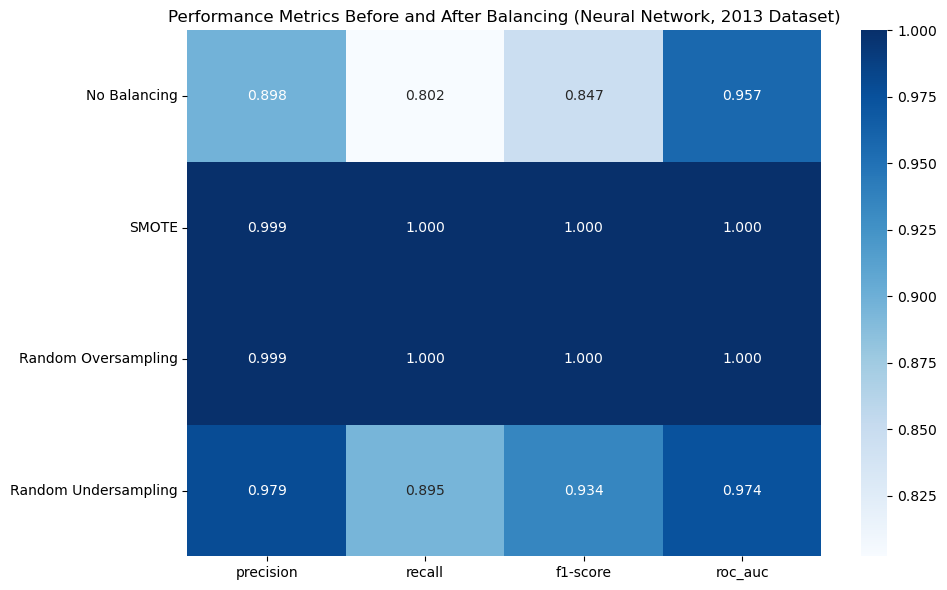


Original Training Class Distribution:
Class
0    199020
1       344
Name: count, dtype: int64

SMOTE Class Distribution:
Class
0    199020
1    199020
Name: count, dtype: int64

Random Oversampling Class Distribution:
Class
0    199020
1    199020
Name: count, dtype: int64

Random Undersampling Class Distribution:
Class
0    344
1    344
Name: count, dtype: int64


In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import traceback

# Set random seed (to ensure rproduciblty of ur results)
np.random.seed(42)
tf.random.set_seed(42)

#create NN model
def create_model(input_shape):
    model = Sequential([
        Input(shape=(input_shape,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

try:
    # Ld the CC
    print("Loading dataset...")
    data = pd.read_csv('/users/absargadoo/creditcard.csv')
    print("Dataset loaded successfully. Shape:", data.shape)
    print("Columns:", data.columns.tolist())

    # Preprocess
    print("Preprocessing data...")
    X = data.drop(['Class'], axis=1)
    y = data['Class']
    print("Class distribution in full dataset:")
    print(pd.Series(y).value_counts())

    # Scale ftrs
    print("Scaling features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split dataset
    print("Splitting dataset...")
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
    print("Training set shape:", X_train.shape, "Test set shape:", X_test.shape)
    print("Training class distribution:")
    print(pd.Series(y_train).value_counts())

    #balancing
    balancing_techniques = {
        'No Balancing': (X_train, y_train),
        'SMOTE': SMOTE(random_state=42, k_neighbors=5).fit_resample(X_train, y_train),
        'Random Oversampling': RandomOverSampler(random_state=42).fit_resample(X_train, y_train),
        'Random Undersampling': RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)
    }

    results = {}
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Evaluate balancing
    for name, (X_balanced, y_balanced) in balancing_techniques.items():
        print(f"\nEvaluating {name} with {n_splits}-fold cross-validation...")
        cv_results = {'precision': [], 'recall': [], 'f1-score': [], 'roc_auc': []}

        # Convert to numpy arrays to avoid index issues
        X_balanced = np.array(X_balanced)
        y_balanced = np.array(y_balanced)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_balanced, y_balanced)):
            print(f"  Fold {fold + 1}/{n_splits}...")
            try:
                X_fold_train, X_fold_val = X_balanced[train_idx], X_balanced[val_idx]
                y_fold_train, y_fold_val = y_balanced[train_idx], y_balanced[val_idx]

                model = create_model(X_train.shape[1])
                model.fit(X_fold_train, y_fold_train, epochs=20, batch_size=64, verbose=1)
                
                y_pred_proba = model.predict(X_fold_val, verbose=0)
                y_pred = (y_pred_proba > 0.5).astype(int).flatten()
                
                report = classification_report(y_fold_val, y_pred, output_dict=True, zero_division=0)
                roc_auc = roc_auc_score(y_fold_val, y_pred_proba)
                
                cv_results['precision'].append(report['1']['precision'])
                cv_results['recall'].append(report['1']['recall'])
                cv_results['f1-score'].append(report['1']['f1-score'])
                cv_results['roc_auc'].append(roc_auc)
            except Exception as e:
                print(f"Error in fold {fold + 1} for {name}: {str(e)}")
                traceback.print_exc()
                continue
        
        results[name] = {
            'precision': np.mean(cv_results['precision']) if cv_results['precision'] else 0,
            'recall': np.mean(cv_results['recall']) if cv_results['recall'] else 0,
            'f1-score': np.mean(cv_results['f1-score']) if cv_results['f1-score'] else 0,
            'roc_auc': np.mean(cv_results['roc_auc']) if cv_results['roc_auc'] else 0
        }

    print("\nConverting results to DataFrame...")
    results_df = pd.DataFrame(results).T

    # Print results
    print("\nPerformance Metrics (Before and After Balancing):")
    print(results_df)

    # Plot
    print("Generating heatmap...")
    plt.figure(figsize=(10, 6))
    sns.heatmap(results_df, annot=True, cmap='Blues', fmt='.3f')
    plt.title('Performance Metrics Before and After Balancing (Neural Network, 2013 Dataset)')
    plt.tight_layout()
    plt.savefig('credit_card_fraud_2013_before_after_heatmap.png')
    plt.show()
    print("\nOriginal Training Class Distribution:")
    print(pd.Series(y_train).value_counts())
    for name, (_, y_balanced) in balancing_techniques.items():
        if name != 'No Balancing':
            print(f"\n{name} Class Distribution:")
            print(pd.Series(y_balanced).value_counts())

except Exception as e:
    print("An error occurred:", str(e))
    traceback.print_exc()
    sys.exit(1)